# Linear Models

Check the performance of SVM and logistic regression on our engineered data sets before moving to more complex models.

In [1]:
%reload_ext autoreload
%autoreload 2
import sys, os
import pandas as pd
import warnings
import numpy as np
from sklearn.model_selection import train_test_split
from pathlib import Path

warnings.filterwarnings('ignore')
DATA_DIR = Path('../src/shared_util/data')
METRICS_DIR = DATA_DIR
CSV_PATH = METRICS_DIR / 'metrics.csv'
LOG = True



from shared_util.metrics import metrics_db
from shared_util.dataio import load_csv



if LOG:
    metrics_db.read_in(CSV_PATH)

METRICS_DB_ID = 0 # update this to not overwrite previous metrics for these models
METRIC_NOTES = "first pass" # global metric notes for this run


In [2]:
df = load_csv('cleaned')
df.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,target
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,0
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,?,...,No,Up,No,No,No,No,No,Ch,Yes,0
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,?,...,No,No,No,No,No,No,No,No,Yes,0
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,?,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,?,...,No,Steady,No,No,No,No,No,Ch,Yes,0


In [3]:
from shared_util.split import train_val_test_split, group_split

X_train, X_validate, X_test, y_train, y_validate, y_test = group_split(df)# train_val_test_split(df)

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_y_dist(y, ax=None, title='Target Variable Distribution'):
    ax = ax or plt.gca()
    sns.countplot(x=y, hue=y, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Readmitted')
    ax.set_ylabel('count')

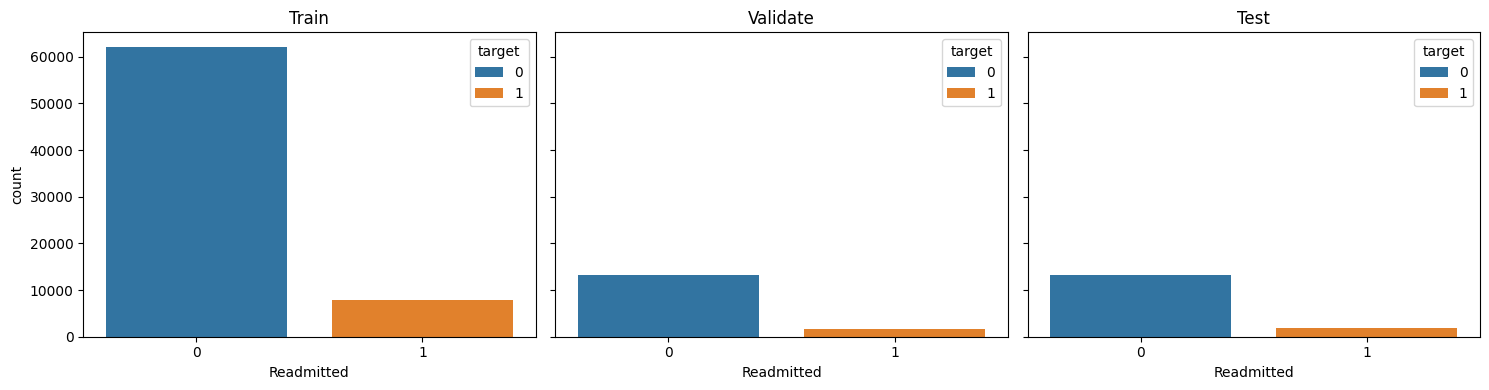

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

plot_y_dist(y_train, ax=axes[0], title='Train')
plot_y_dist(y_validate, ax=axes[1], title='Validate')
plot_y_dist(y_test, ax=axes[2], title='Test')

plt.tight_layout()
plt.show()

In [6]:
# from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold

# def make_cv():
#     return StratifiedKFold(
#     n_splits=10,
#     shuffle=True,
#     random_state=42
#     )


## Baseline Logistic Regression

In [7]:
from sklearn.linear_model import SGDClassifier
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler
from shared_util.pipeline import CleaningPipeline

from shared_util.baseline import get_baseline_score
from imblearn.pipeline import Pipeline


print('Baseline SGD Classifier')

roc_auc = get_baseline_score(
    SGDClassifier(random_state=42),
    RandomUnderSampler(random_state=42),
    X_train,
    y_train,
    scaler=StandardScaler(),
    preprocessor=CleaningPipeline(create_interactions=True)
    )


if LOG:
    metrics_db.log_metric(
        metric_id=METRICS_DB_ID,
        model='sgd',
        threshold_notes='base',
        data='train',
        pipeline_notes='under_sample',
        notes=METRIC_NOTES,
        roc_auc=roc_auc
    )



Baseline SGD Classifier
roc_auc score per fold:  [0.59278445 0.5874678  0.57554482 0.58604855 0.59339313]
mean roc_auc score:  0.5870477506087299
logged row: (0, sgd, train, base, under_sample)


In [8]:
# try SMOTE
from imblearn.over_sampling import SMOTE

print('Baseline ROC_AUC using SMOTE')

roc_auc = get_baseline_score(
    SGDClassifier(random_state=42),
    SMOTE(random_state=42),
    X_train,
    y_train,
    scaler=StandardScaler(),
    preprocessor=CleaningPipeline(create_interactions=True)
    )

if LOG:
    metrics_db.log_metric(
        metric_id=METRICS_DB_ID,
        threshold_notes='base',
        data='train',
        model='sgd',
        pipeline_notes='SMOTE',
        notes=METRIC_NOTES,
        roc_auc=roc_auc
    )


Baseline ROC_AUC using SMOTE
roc_auc score per fold:  [0.56072186 0.56087146 0.55755789 0.53225547 0.56997119]
mean roc_auc score:  0.5562755752085948
logged row: (0, sgd, train, base, SMOTE)


In [9]:
def make_base_sgd(use_smote=False):
    return Pipeline([
        ('preprocessor', CleaningPipeline(create_interactions=True)),
        ('sampler',SMOTE(random_state=42) if use_smote else RandomUnderSampler(random_state=42)),
        ('scaler', StandardScaler()),
        ('model', SGDClassifier(random_state=42))
    ])

In [10]:
# hyperparam search for SGD
from sklearn.model_selection import RandomizedSearchCV
from shared_util.baseline import make_group_cv


sgd_param_grid = {
    "model__loss": ["log_loss", "modified_huber", "hinge", "squared_hinge"],
    "model__penalty": ["l2", "l1", "elasticnet"],
    "model__alpha": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2],
    "model__l1_ratio": [0.1, 0.5, 0.9],
    "model__learning_rate": ["constant", "optimal", "invscaling", "adaptive"],
    "model__eta0": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1],
    "model__max_iter": [100, 500, 1000],
    "model__tol": [1e-3, 1e-4],
    "model__class_weight": [None, "balanced"],
    "model__average": [False, True, 5, 10],
    "model__shuffle": [True],
}

rs = RandomizedSearchCV(
    estimator=make_base_sgd(),
    param_distributions=sgd_param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=make_group_cv(),
    n_jobs=-1,
    random_state=42,
    refit=True
)

rs.fit(X_train, y_train, groups=X_train['patient_nbr'])

print(f'Best ROC_AUC (cv): {rs.best_score_}')
print(f'best params: {rs.best_params_}')

res_df = pd.DataFrame(
    rs.cv_results_
).sort_values('rank_test_score').reset_index(drop=True)
res_df[['rank_test_score','mean_test_score','std_test_score','params']].head(10)

Best ROC_AUC (cv): 0.6554218451240015
best params: {'model__tol': 0.0001, 'model__shuffle': True, 'model__penalty': 'l1', 'model__max_iter': 500, 'model__loss': 'modified_huber', 'model__learning_rate': 'invscaling', 'model__l1_ratio': 0.9, 'model__eta0': 0.003, 'model__class_weight': None, 'model__average': 10, 'model__alpha': 0.001}


,rank_test_score,mean_test_score,std_test_score,params
0,1,0.655422,0.007799,"{'model__tol': 0.0001, 'model__shuffle': True,..."
1,2,0.655192,0.008990,"{'model__tol': 0.001, 'model__shuffle': True, ..."
2,3,0.654321,0.008682,"{'model__tol': 0.001, 'model__shuffle': True, ..."
3,4,0.653997,0.008317,"{'model__tol': 0.001, 'model__shuffle': True, ..."
4,5,0.653821,0.008126,"{'model__tol': 0.0001, 'model__shuffle': True,..."
5,6,0.653514,0.008318,"{'model__tol': 0.001, 'model__shuffle': True, ..."
6,7,0.653061,0.008074,"{'model__tol': 0.001, 'model__shuffle': True, ..."
7,8,0.652169,0.008281,"{'model__tol': 0.0001, 'model__shuffle': True,..."
8,9,0.647170,0.008088,"{'model__tol': 0.0001, 'model__shuffle': True,..."
9,10,0.646974,0.007915,"{'model__tol': 0.0001, 'model__shuffle': True,..."


In [11]:
# Best ROC_AUC (cv): 0.6549746228889155
# best params: {'model__tol': 0.001, 'model__shuffle': True, 'model__penalty': 'l1', 'model__max_iter': 1000, 'model__loss': 'log_loss', 'model__learning_rate': 'constant', 'model__l1_ratio': 0.1, 'model__eta0': 0.0003, 'model__class_weight': 'balanced', 'model__average': False, 'model__alpha': 0.0001}

In [12]:
# predict on validate set before threshold changes
from shared_util.metrics.scoring import get_scores, best_threshold_by_fbeta, plot_scoring
from shared_util.metrics.printing import print_metrics

sgd_est = rs.best_estimator_
sgd_scores = get_scores(sgd_est, X_validate)

y_pred = rs.best_estimator_.predict(X_validate) #type: ignore

print_metrics(
              y_true=y_validate, 
              y_pred=y_pred, 
              y_proba=sgd_scores,
              metrics_db_id=METRICS_DB_ID,
              metrics_notes=METRIC_NOTES,
              data='validate',
              model='sgd',
              hyperparam_notes='tuned best roc',
              pipeline_notes='under_sample',
              log=LOG
)



ROC_AUC:     0.6497201768279501
Accuracy:      0.6592163906073305
F1 score:      0.26361937616788844
Precision:     0.1744340878828229
Recall:        0.5394117647058824

Confusion matrix:

TN: 8993, FP: 4340, FN: 783, TP: 917

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.67      0.78     13333
           1       0.17      0.54      0.26      1700

    accuracy                           0.66     15033
   macro avg       0.55      0.61      0.52     15033
weighted avg       0.84      0.66      0.72     15033

logged row: (0, sgd, validate, base, under_sample)


Best threshold (F2): 0.4179
Precision: 0.147  Recall: 0.811  F2: 0.426


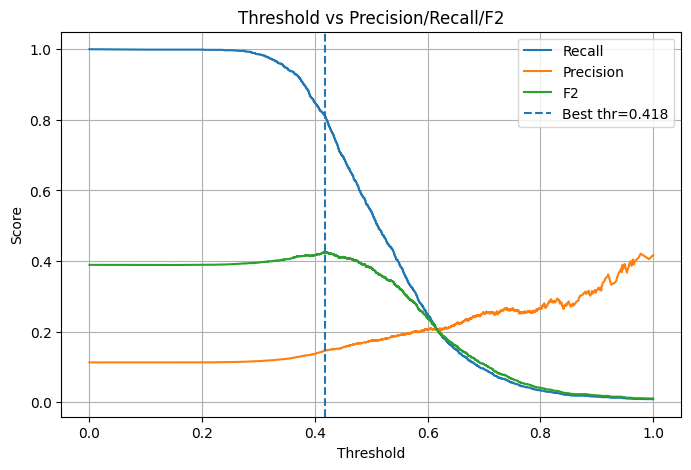

In [13]:
# decide threshold on validation set
info = best_threshold_by_fbeta(y_validate, sgd_scores, beta=2.0)
best_thresh = info['threshold']
y_pred_custom = (sgd_scores >= best_thresh).astype(int)

print(f"Best threshold (F2): {best_thresh:.4f}")
print(f"Precision: {info['precision']:.3f}  Recall: {info['recall']:.3f}  F2: {info['fbeta']:.3f}")

plot_scoring(info['curve'])

In [14]:
# use the threshold for predicitons on the held out test set

from shared_util.metrics.printing import print_metrics

sgd_scores_test = get_scores(sgd_est, X_test)

y_pred_custom_test = (sgd_scores_test >= best_thresh).astype(int)

print_metrics(
    y_true=y_test,
    y_pred=y_pred_custom_test,
    y_proba=sgd_scores_test,
    data='test',
    threshold_notes='f2_weighted',
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRIC_NOTES,
    log=LOG,
    model='sgd',
    hyperparam_notes='tuned best ROC',
    pipeline_notes='under_sample'

)

ROC_AUC:     0.6564595721371213
Accuracy:      0.4357123940677966
F1 score:      0.25660706498037505
Precision:     0.15265670402656703
Recall:        0.8042646254784035

Confusion matrix:

TN: 5110, FP: 8165, FN: 358, TP: 1471

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.38      0.55     13275
           1       0.15      0.80      0.26      1829

    accuracy                           0.44     15104
   macro avg       0.54      0.59      0.40     15104
weighted avg       0.84      0.44      0.51     15104

logged row: (0, sgd, test, f2_weighted, under_sample)


In [15]:
# SVM
from sklearn.svm import SVC
from shared_util.baseline import get_baseline_score

roc_auc = get_baseline_score(
    SVC(random_state=42),
    RandomUnderSampler(random_state=42),
    X_train,
    y_train,
    scaler=StandardScaler(),
    preprocessor=CleaningPipeline(create_interactions=True)
)

if LOG:
    metrics_db.log_metric(
        metric_id=METRICS_DB_ID,
        threshold_notes='base',
        data='train',
        model='svc',
        pipeline_notes='under_sample',
        notes=METRIC_NOTES,
        roc_auc=roc_auc
    )






roc_auc score per fold:  [0.65356521 0.64807543 0.64171616 0.63700077 0.66364904]
mean roc_auc score:  0.6488013216824484
logged row: (0, svc, train, base, under_sample)


In [16]:
# running smote did not get a result after 6 hours so leaving it out for now

## Hyperparameter sweep for SVM

In [20]:
# this cell takes a very long time to run
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV #type: ignore
from scipy.stats import loguniform
from sklearn.model_selection import StratifiedGroupKFold





def make_base_svc():
    return Pipeline([
        ('preprocessor', CleaningPipeline(create_interactions=True)),
        ('sampler', RandomUnderSampler(random_state=42)),
        ('scaler', StandardScaler()),
        ('model', SVC(random_state=42, cache_size=16384))
    ])
# limited param search due to computation time
svc_param_grid = {
    "model__kernel": ["rbf"],
    "model__C": loguniform(1e-3, 1e3),
    "model__gamma": [0.001, 0.01, 0.1, 1],
    "model__class_weight": ["balanced"],
    "model__shrinking": [False],
}

# reduced to 5 folds again for computation time

cv_svc = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
    )

rs_hsvc = RandomizedSearchCV(
    estimator=make_base_svc(),
    param_distributions=svc_param_grid,
   # n_iter=50,  
    scoring='roc_auc',
    cv=cv_svc,
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=2
)



rs_hsvc.fit(X_train, y_train, groups=X_train['patient_nbr'])

print(f'Best ROC_AUC (cv): {rs_hsvc.best_score_}')
print(f'Best params: {rs_hsvc.best_params_}')

res_df = pd.DataFrame(rs_hsvc.cv_results_).sort_values('rank_test_score').reset_index(drop=True)
res_df[['rank_test_score','mean_test_score','std_test_score','params']].head(10)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END model__C=17.718847354806815, model__class_weight=balanced, model__gamma=0.01, model__kernel=rbf, model__shrinking=False; total time= 3.9min
[CV] END model__C=0.002231010801867922, model__class_weight=balanced, model__gamma=1, model__kernel=rbf, model__shrinking=False; total time= 4.0min
[CV] END model__C=3.907967156822881, model__class_weight=balanced, model__gamma=0.1, model__kernel=rbf, model__shrinking=False; total time= 4.0min
[CV] END model__C=0.002231010801867922, model__class_weight=balanced, model__gamma=1, model__kernel=rbf, model__shrinking=False; total time= 4.1min
[CV] END model__C=0.1767016940294795, model__class_weight=balanced, model__gamma=0.001, model__kernel=rbf, model__shrinking=False; total time= 4.2min
[CV] END model__C=0.1767016940294795, model__class_weight=balanced, model__gamma=0.001, model__kernel=rbf, model__shrinking=False; total time= 4.2min
[CV] END model__C=0.1767016940294795, model__cl

,rank_test_score,mean_test_score,std_test_score,params
0,1,0.645753,0.008988,"{'model__C': 0.1767016940294795, 'model__class..."
1,2,0.586631,0.006853,"{'model__C': 17.718847354806815, 'model__class..."
2,3,0.578666,0.005699,"{'model__C': 0.4731474644815003, 'model__class..."
3,4,0.566321,0.006419,"{'model__C': 98.77700294007911, 'model__class_..."
4,5,0.563269,0.004094,"{'model__C': 3.907967156822881, 'model__class_..."
5,6,0.533764,0.004069,"{'model__C': 0.10051981180656774, 'model__clas..."
6,7,0.533761,0.004073,"{'model__C': 0.012606912518374074, 'model__cla..."
7,8,0.533719,0.004172,"{'model__C': 0.002231010801867922, 'model__cla..."
8,9,0.533716,0.004180,"{'model__C': 0.0021800651586435186, 'model__cl..."
9,10,0.533662,0.004163,"{'model__C': 0.0010108171343846386, 'model__cl..."


In [ ]:
# The above code block generates best hyperparams for our SVC model:
# Best ROC_AUC (cv): 0.6457530427983966
# Best params: {'model__C': np.float64(0.1767016940294795), 'model__class_weight': 'balanced', 'model__gamma': 0.001, 'model__kernel': 'rbf', 'model__shrinking': False}

In [23]:
# predict on validate set before threshold changes
svm_est = rs_hsvc.best_estimator_ 

cleaning_pipe = CleaningPipeline(create_interactions=True)

X_train_cleaned = cleaning_pipe.fit_transform(X_train)

X_validate_cleaned = cleaning_pipe.transform(X_validate)

X_test_cleaned = cleaning_pipe.transform(X_test)

display(X_validate.head())
display(X_validate_cleaned.head())

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
15,73578,86328819,AfricanAmerican,Male,[60-70),1,3,7,12,?,...,No,No,Up,No,No,No,No,No,Ch,Yes
26,236316,40523301,Caucasian,Male,[80-90),1,3,7,6,Cardiology,...,No,No,No,No,No,No,No,No,Ch,Yes
30,253380,56480238,AfricanAmerican,Female,[60-70),1,1,7,6,?,...,No,No,Steady,No,No,No,No,No,Ch,Yes
33,293058,114715242,Caucasian,Male,[60-70),2,6,2,5,?,...,No,No,Steady,No,No,No,No,No,No,Yes
42,449142,66274866,Caucasian,Male,[50-60),1,1,7,3,Family/GeneralPractice,...,No,No,Steady,No,No,No,No,No,Ch,Yes


,encounter_id,patient_nbr,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,...,i_discharge_loc_transfer_inpatient__specialty_cat_missing,i_discharge_loc_transfer_inpatient__specialty_cat_other,i_discharge_loc_transfer_inpatient__specialty_cat_pcp,i_discharge_loc_transfer_inpatient__specialty_cat_surgery,i_discharge_loc_unknown__specialty_cat_cardiology,i_discharge_loc_unknown__specialty_cat_internal_medicine,i_discharge_loc_unknown__specialty_cat_missing,i_discharge_loc_unknown__specialty_cat_other,i_discharge_loc_unknown__specialty_cat_pcp,i_discharge_loc_unknown__specialty_cat_surgery
15,73578,86328819,12,75,5,13,0,0,0,9,...,0,1,0,0,0,0,0,0,0,0
26,236316,40523301,6,64,3,18,0,0,0,7,...,0,0,0,0,0,0,0,0,0,0
30,253380,56480238,6,87,0,18,0,0,0,9,...,0,0,0,0,0,0,0,0,0,0
33,293058,114715242,5,37,0,18,0,0,0,8,...,0,0,0,0,0,0,0,0,0,0
42,449142,66274866,3,59,0,11,0,0,0,6,...,0,0,0,0,0,0,0,0,0,0


In [ ]:




svm_scores = get_scores(svm_est, X_validate_cleaned)

y_pred = svm_est.predict(X_validate_cleaned) #type: ignore

print_metrics(
              y_true=y_validate, 
              y_pred=y_pred, 
              y_proba=svm_scores,
              data='validate',
              metrics_db_id=METRICS_DB_ID,
              metrics_notes=METRIC_NOTES,
              model='svc',
              hyperparam_notes='tuned best roc, uses HalvingRandomSearchCV',
              pipeline_notes='under_sample',
              log=LOG
)



KeyError: 'diag_1'

Best threshold (F2): 0.4357
Precision: 0.161  Recall: 0.710  F2: 0.423


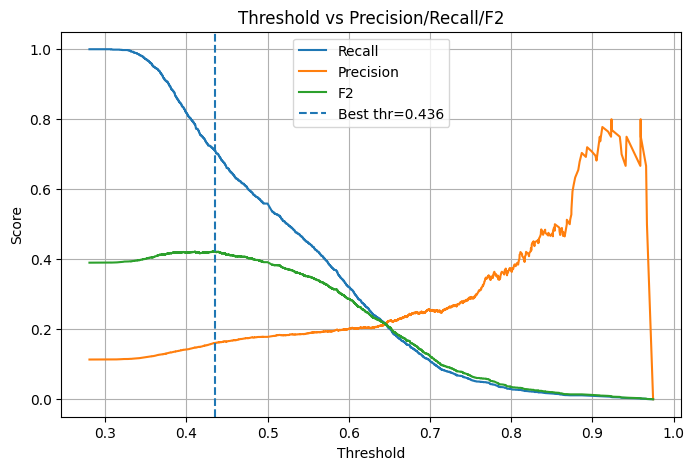

In [ ]:
# threshold sweep using validation set
from shared_util.metrics.scoring import get_scores, best_threshold_by_fbeta, plot_scoring



info = best_threshold_by_fbeta(y_validate, svm_scores, beta=2.0)

best_thresh = info["threshold"]
y_pred_custom = (svm_scores >= best_thresh).astype(int)

print(f"Best threshold (F2): {best_thresh:.4f}")
print(f"Precision: {info['precision']:.3f}  Recall: {info['recall']:.3f}  F2: {info['fbeta']:.3f}")

plot_scoring(info['curve'])

In [ ]:
# held out test prediction using calculated threshold

# this inference took ~25 seconds, considering other models took <1 second, thats a significant downside to SVC

svm_scores_test = get_scores(svm_est, X_test)

y_pred_test_svm = (svm_scores_test >= best_thresh).astype(int)


In [ ]:
from shared_util.metrics.printing import print_metrics

print ('Held out test metrics for (Support Vector Classifier)')

print_metrics(
              y_true=y_test, 
              y_pred=y_pred_test_svm, 
              y_proba=svm_scores_test,
              data='test',
              threshold_notes='f2_weighted',
              metrics_db_id=METRICS_DB_ID,
              metrics_notes=METRIC_NOTES,
              model='svc',
              hyperparam_notes='tuned best roc, uses HalvingRandomSearchCV',
              pipeline_notes='under_sample',
              log=LOG
              )

Held out test metrics for (Support Vector Classifier)
ROC_AUC:     0.6546909074460283
Accuracy:      0.5537795537795538
F1 score:      0.2624394539850286
Precision:     0.16151761517615176
Recall:        0.6995305164319249

Confusion matrix:

TN: 7123, FP: 6188, FN: 512, TP: 1192

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.54      0.68     13311
           1       0.16      0.70      0.26      1704

    accuracy                           0.55     15015
   macro avg       0.55      0.62      0.47     15015
weighted avg       0.85      0.55      0.63     15015

logged row: (0, svc, test, f2_weighted, under_sample)


Both SVM and the SGD classifier both achieved above expected results compared to previous literature, which showed linear models performing, generally, with a ROC_AUC below 0.600.

